In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
plt.rcParams['figure.figsize'] = (10, 5)
plt.rcParams['font.size'] = 9

In [3]:
cols = ['unit', 'cycle', 'op1', 'op2', 'op3'] + [f'sensor{i}' for i in range(1, 22)]

# Load FD001 training data
data_path = os.path.join('CMAPSSData', 'train_FD001.txt')
train = pd.read_csv(data_path, sep=r'\s+', header=None, names=cols)

print(f"Loaded {train.shape[0]:,} rows and {train.shape[1]} columns across {train['unit'].nunique()} engines.")
print(f"Cycle life range: {train.groupby('unit')['cycle'].max().min()} to {train.groupby('unit')['cycle'].max().max()} cycles.")

train.head()

Loaded 20,631 rows and 26 columns across 100 engines.
Cycle life range: 128 to 362 cycles.


,unit,cycle,op1,op2,op3,sensor1,sensor2,sensor3,sensor4,sensor5,...,sensor12,sensor13,sensor14,sensor15,sensor16,sensor17,sensor18,sensor19,sensor20,sensor21
0,1,1,-0.0007,-0.0004,100.0,518.67,641.82,1589.70,1400.60,14.62,...,521.66,2388.02,8138.62,8.4195,0.03,392,2388,100.0,39.06,23.4190
1,1,2,0.0019,-0.0003,100.0,518.67,642.15,1591.82,1403.14,14.62,...,522.28,2388.07,8131.49,8.4318,0.03,392,2388,100.0,39.00,23.4236
2,1,3,-0.0043,0.0003,100.0,518.67,642.35,1587.99,1404.20,14.62,...,522.42,2388.03,8133.23,8.4178,0.03,390,2388,100.0,38.95,23.3442
3,1,4,0.0007,0.0000,100.0,518.67,642.35,1582.79,1401.87,14.62,...,522.86,2388.08,8133.83,8.3682,0.03,392,2388,100.0,38.88,23.3739
4,1,5,-0.0019,-0.0002,100.0,518.67,642.37,1582.85,1406.22,14.62,...,522.19,2388.04,8133.80,8.4294,0.03,393,2388,100.0,38.90,23.4044


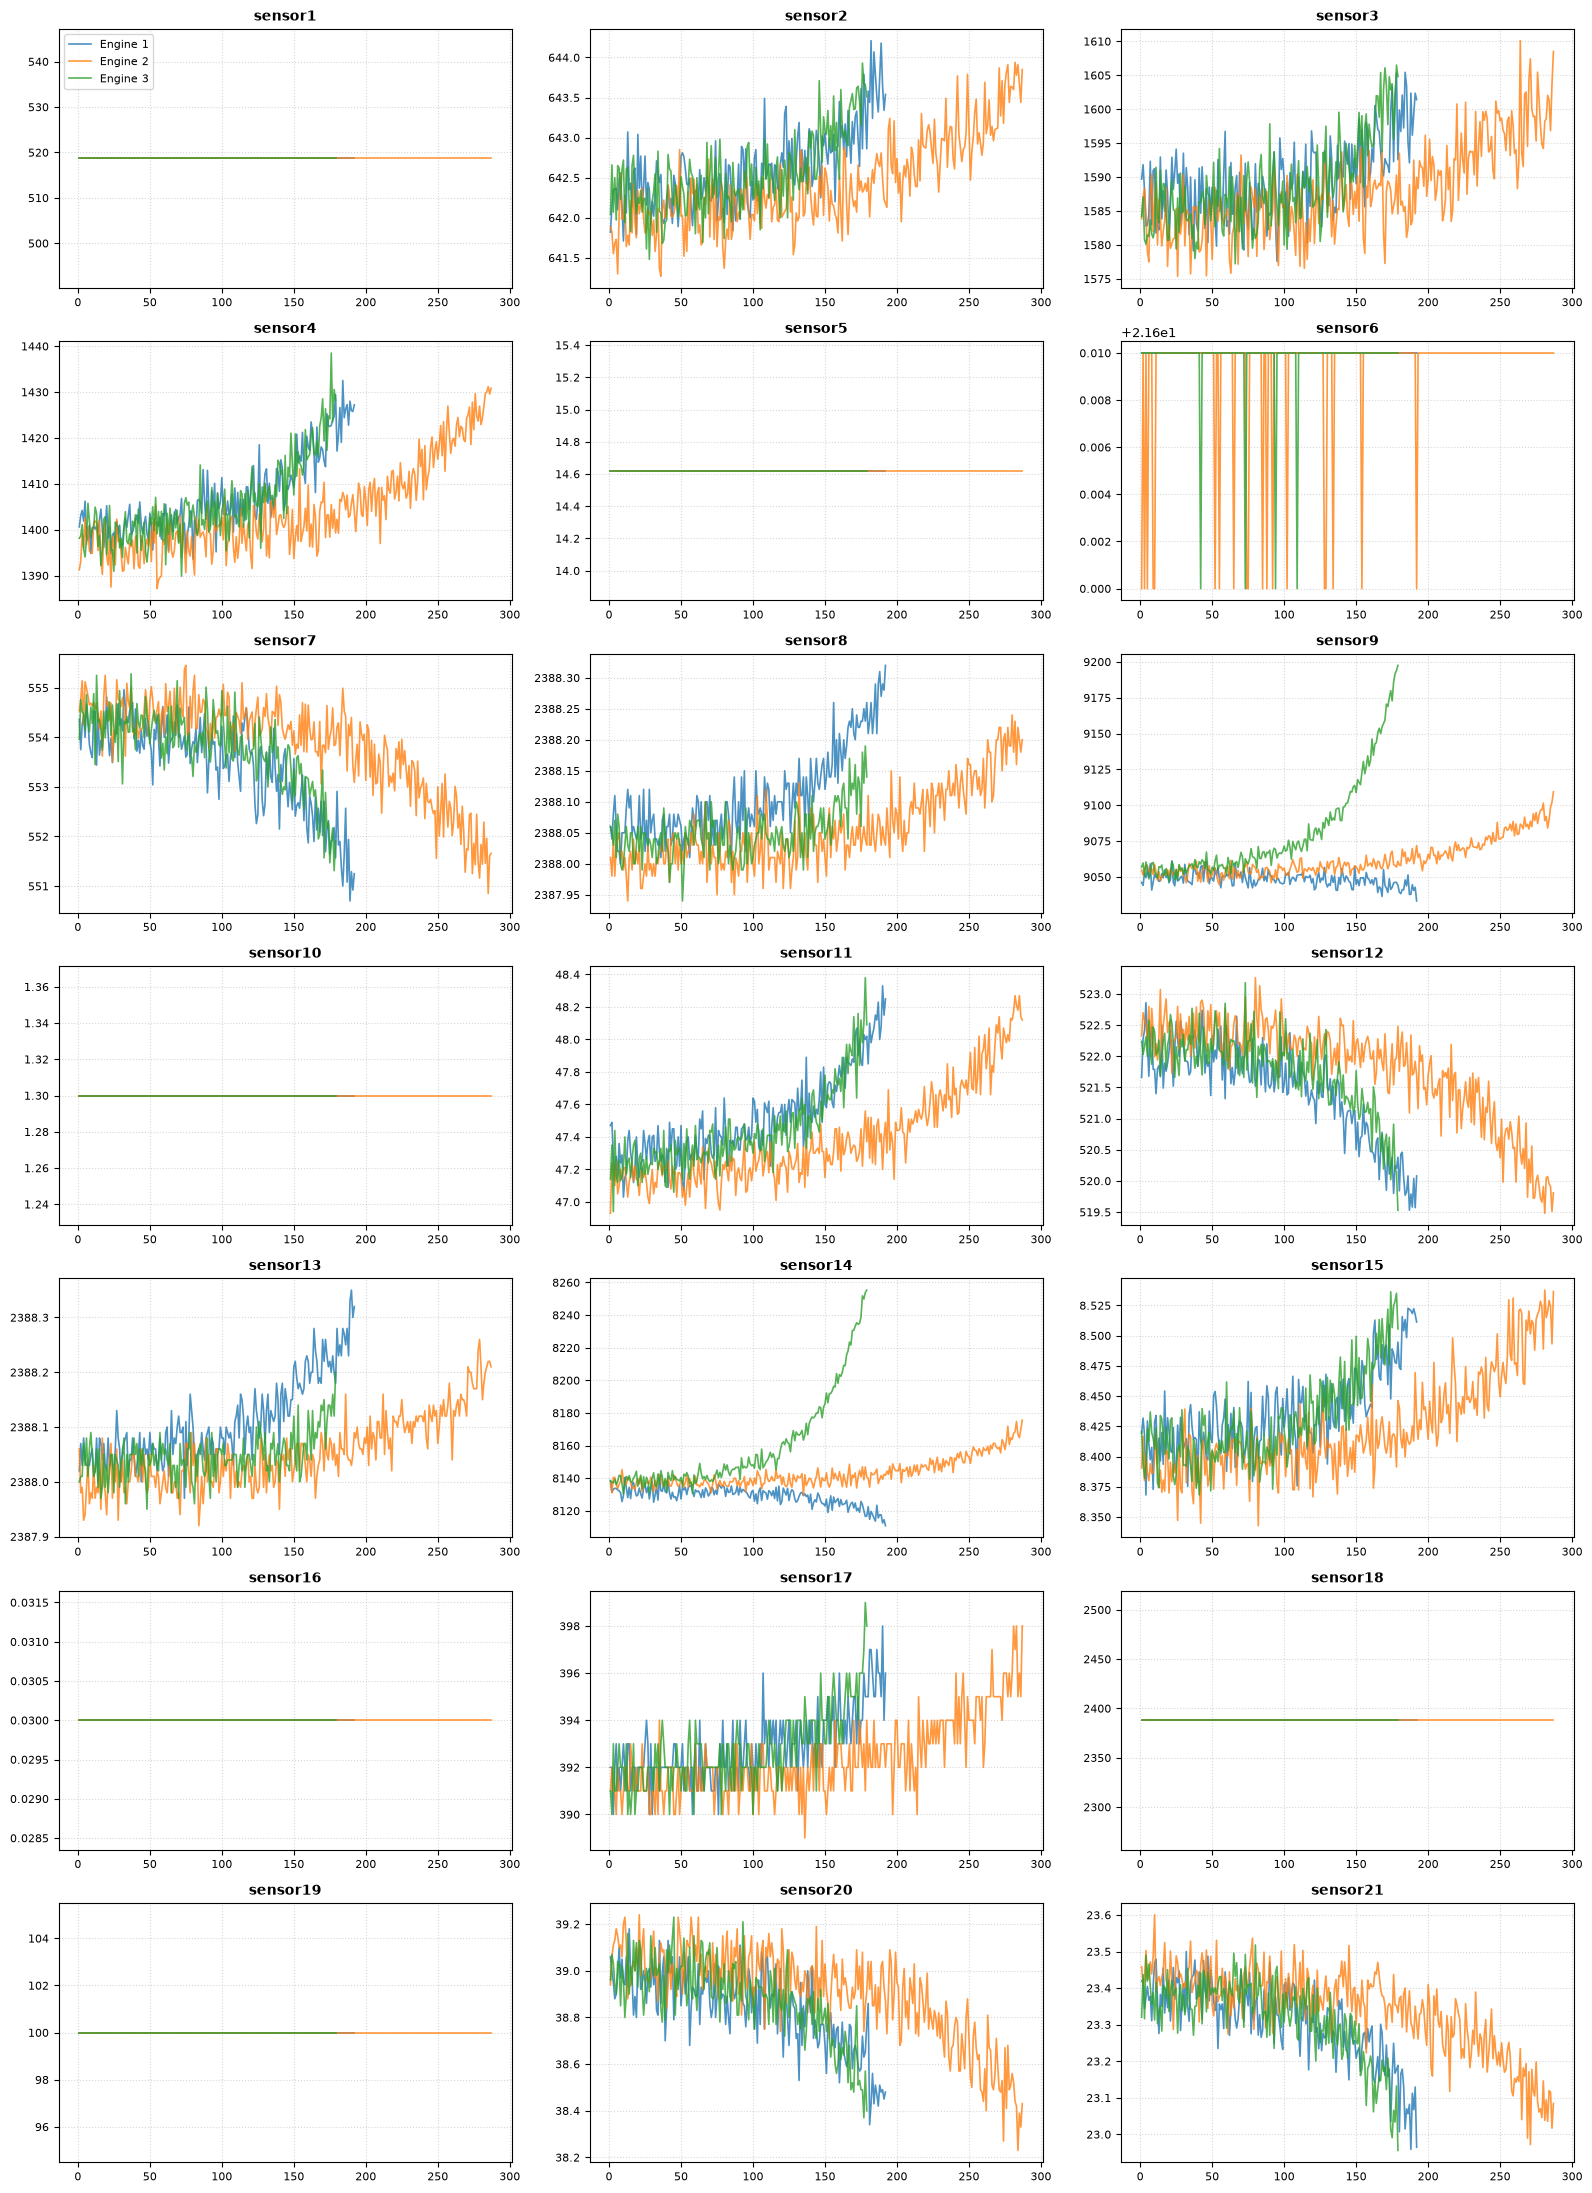

In [5]:
# Select 3 sample engines across their entire lifecycle
sample_units = [1, 2, 3]
sensor_cols = [f'sensor{i}' for i in range(1, 22)]

fig, axes = plt.subplots(7, 3, figsize=(16, 22))
axes = axes.flatten()

for idx, sensor in enumerate(sensor_cols):
    ax = axes[idx]
    for unit in sample_units:
        engine_df = train[train['unit'] == unit]
        ax.plot(engine_df['cycle'], engine_df[sensor], label=f'Engine {unit}', alpha=0.8, lw=1.2)
    
    ax.set_title(sensor, fontsize=10, fontweight='bold')
    ax.tick_params(labelsize=8)
    ax.grid(True, linestyle=":", alpha=0.5)

axes[0].legend(fontsize=8, loc='upper left')
plt.tight_layout()
plt.show()

In [6]:
# 1. Identify sensors with zero variance across the whole dataset
sensor_stds = train[sensor_cols].std()
dead_sensors = sensor_stds[sensor_stds == 0].index.tolist()

print(f"Dead sensors (zero variance, dropped): {dead_sensors}")

# 2. Select core degradation signals (all upward-drifting thermal and pressure metrics)
# sensor2  = T24 (LPC outlet temperature)
# sensor3  = T30 (HPC outlet temperature)
# sensor4  = T50 (LPT outlet temperature)
# sensor11 = Ps30 (Static pressure at HPC outlet)
SIGNAL_SENSORS = ['sensor2', 'sensor3', 'sensor4', 'sensor11']
BASELINE_CYCLES = 20

print(f"Selected signal sensors: {SIGNAL_SENSORS}")
print(f"Baseline window: First {BASELINE_CYCLES} cycles")

Dead sensors (zero variance, dropped): ['sensor1', 'sensor10', 'sensor18', 'sensor19']
Selected signal sensors: ['sensor2', 'sensor3', 'sensor4', 'sensor11']
Baseline window: First 20 cycles


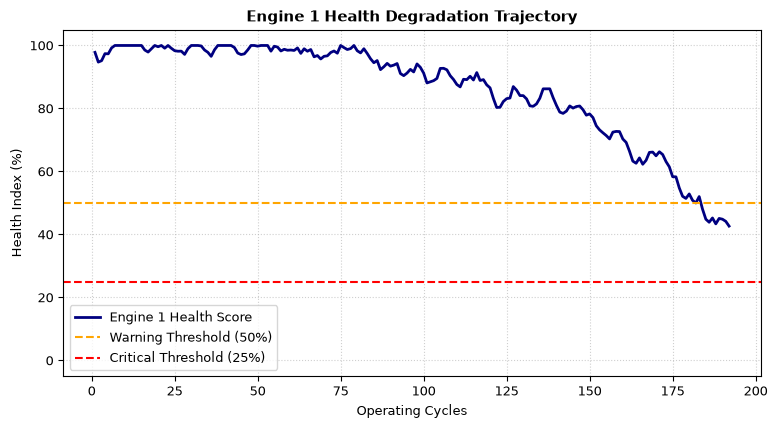

In [10]:
def compute_health_score(unit_df, baseline_cycles=20):
    df_unit = unit_df.sort_values('cycle').copy()
    
    # Define the healthy baseline window
    baseline = df_unit[df_unit['cycle'] <= baseline_cycles]
    
    z_scores = []
    for s in SIGNAL_SENSORS:
        mu = baseline[s].mean()
        std = baseline[s].std()
        
        # Guard against zero division
        if std == 0 or np.isnan(std):
            std = 1e-4
            
        # Upward drift z-score
        z = (df_unit[s] - mu) / std
        z_scores.append(z)
        
    # Composite drift: average across our 4 signal sensors
    df_unit['composite_drift'] = pd.concat(z_scores, axis=1).mean(axis=1)
    
    # 5-cycle rolling average to remove short-term noise
    smoothed_drift = df_unit['composite_drift'].rolling(window=5, min_periods=1).mean()
    
    # Map drift to Health Score: baseline drift ~0 -> 100%, drift of +10 sigma -> 0%
    df_unit['health_score'] = np.clip(100 - (smoothed_drift * 10), 0, 100)
    return df_unit

# Validate on Engine 1
unit1_scored = compute_health_score(train[train['unit'] == 1])

plt.figure(figsize=(9, 4.5))
plt.plot(unit1_scored['cycle'], unit1_scored['health_score'], color='navy', lw=2, label='Engine 1 Health Score')
plt.axhline(50, color='orange', linestyle='--', label='Warning Threshold (50%)')
plt.axhline(25, color='red', linestyle='--', label='Critical Threshold (25%)')

plt.title("Engine 1 Health Degradation Trajectory", fontsize=11, fontweight='bold')
plt.xlabel("Operating Cycles")
plt.ylabel("Health Index (%)")
plt.ylim(-5, 105)
plt.grid(True, linestyle=":", alpha=0.6)
plt.legend(loc="lower left")

# 1. SAVE FIRST (so it captures the drawn lines)
plt.savefig("engine_1_validation.png", dpi=150, bbox_inches="tight")

# 2. SHOW SECOND (which resets the canvas)
plt.show()

In [7]:
print("Scoring all 100 engines across the fleet...")
scored_fleet = train.groupby('unit', group_keys=False).apply(compute_health_score)

fleet_summary = []

for unit_id, group in scored_fleet.groupby('unit'):
    last_row = group.iloc[-1]
    final_cycle = int(last_row['cycle'])
    final_health = round(last_row['health_score'], 1)
    
    # Calculate recent decline rate over the last 15 cycles (% health lost per cycle)
    recent = group[group['cycle'] > (final_cycle - 15)]
    health_drop = recent.iloc[0]['health_score'] - recent.iloc[-1]['health_score']
    decline_rate = round(health_drop / max(1, len(recent)), 2)
    
    # Industrial triage categories
    if final_health < 50:
        priority = "CRITICAL"
    elif final_health < 75:
        priority = "WARNING"
    else:
        priority = "HEALTHY"
        
    fleet_summary.append({
        'unit': unit_id,
        'current_cycle': final_cycle,
        'health_score': final_health,
        'decline_rate_per_cycle': max(0.0, decline_rate),
        'priority': priority
    })

fleet_df = pd.DataFrame(fleet_summary)

# Sort by lowest health first, and highest decline rate second
fleet_df = fleet_df.sort_values(
    by=['health_score', 'decline_rate_per_cycle'], 
    ascending=[True, False]
).reset_index(drop=True)

# Export the maintenance dispatch table to CSV
fleet_df.to_csv("fleet_maintenance_priority.csv", index=False)
print("Saved complete fleet table to 'fleet_maintenance_priority.csv'!")

# Display top 10 engines needing service
print("\n--- TOP 10 ENGINES REQUIRING IMMEDIATE DISPATCH/SERVICE ---")
fleet_df.head(10)

Scoring all 100 engines across the fleet...
Saved complete fleet table to 'fleet_maintenance_priority.csv'!

--- TOP 10 ENGINES REQUIRING IMMEDIATE DISPATCH/SERVICE ---


C:\Users\nirma\AppData\Local\Temp\ipykernel_17308\3200773089.py:2: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  scored_fleet = train.groupby('unit', group_keys=False).apply(compute_health_score)


,unit,current_cycle,health_score,decline_rate_per_cycle,priority
0,33,200,13.4,1.82,CRITICAL
1,44,192,16.5,1.60,CRITICAL
2,83,293,16.9,1.28,CRITICAL
3,5,269,18.1,1.29,CRITICAL
4,59,231,18.9,1.35,CRITICAL
5,10,222,20.6,1.25,CRITICAL
6,2,287,21.3,0.88,CRITICAL
7,50,198,21.7,1.37,CRITICAL
8,15,207,23.0,1.29,CRITICAL
9,54,257,23.9,1.15,CRITICAL


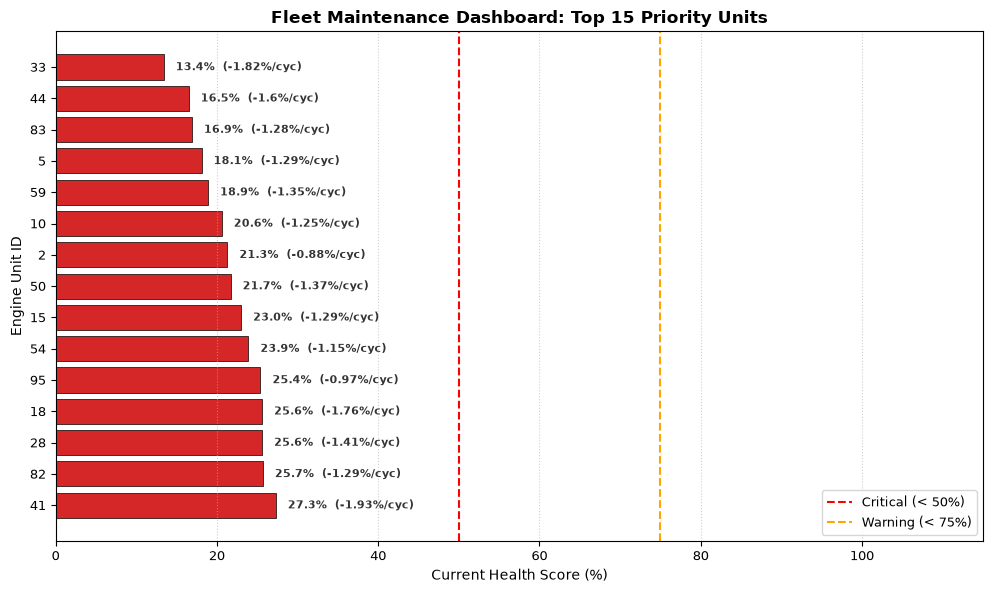

Saved dashboard graphic to 'fleet_maintenance_dashboard.png'!


In [8]:
top_15 = fleet_df.head(15).copy()

# Color mapping based on urgency
colors = [
    '#d62728' if p == 'CRITICAL' else '#ff7f0e' if p == 'WARNING' else '#2ca02c' 
    for p in top_15['priority']
]

plt.figure(figsize=(10, 6))
bars = plt.barh(top_15['unit'].astype(str), top_15['health_score'], color=colors, edgecolor='black', linewidth=0.5)

# Add threshold guideline lines
plt.axvline(50, color='red', linestyle='--', linewidth=1.5, label='Critical (< 50%)')
plt.axvline(75, color='orange', linestyle='--', linewidth=1.5, label='Warning (< 75%)')

# Invert Y so lowest health (#1 priority) is at the very top
plt.gca().invert_yaxis()

# Annotate each bar with its exact score and decline velocity
for bar, (_, row) in zip(bars, top_15.iterrows()):
    width = bar.get_width()
    plt.text(width + 1.5, bar.get_y() + bar.get_height()/2, 
             f"{row['health_score']}%  (-{row['decline_rate_per_cycle']}%/cyc)", 
             va='center', fontsize=8, fontweight='bold', color='#333333')

plt.title("Fleet Maintenance Dashboard: Top 15 Priority Units", fontsize=12, fontweight='bold')
plt.xlabel("Current Health Score (%)", fontsize=10)
plt.ylabel("Engine Unit ID", fontsize=10)
plt.xlim(0, 115)
plt.grid(axis='x', linestyle=':', alpha=0.6)
plt.legend(loc='lower right')
plt.tight_layout()

# Save the dashboard graphic
plt.savefig("fleet_maintenance_dashboard.png", dpi=150)
plt.show()

print("Saved dashboard graphic to 'fleet_maintenance_dashboard.png'!")